# Phase 3: Deep Generative Models (PlantVillage)

Questions 3.7, 3.8, 3.9, 3.10

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## Dataset: PlantVillage (color)
Same split as Assignment 2 Phase 2: 70% train, 15% val, 15% test, seed=42, 64x64.

In [2]:
DATA_DIR = '../Datasets/plantvillage_dataset/color'

# VAE works on [0,1] range; no normalization shift so reconstruction is easier to interpret
transform = transforms.Compose([
    transforms.Resize((64, 64)),   # 64x64 keeps VAE tractable
    transforms.ToTensor(),         # -> [0, 1]
])

full_dataset = torchvision.datasets.ImageFolder(root=DATA_DIR, transform=transform)
N = len(full_dataset)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

gen = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=gen
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 38013 | Val: 8145 | Test: 8147


---
## Q3.7 - ELBO Implementation: Convolutional VAE

In [3]:
class ConvVAE(nn.Module):
    """Convolutional VAE with encoder and decoder.
    Input: (B, 3, 64, 64)  |  Latent dim: LATENT_DIM
    """

    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 64 -> 32 -> 16 -> 8 -> 4
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  32, 4, stride=2, padding=1), nn.ReLU(),  # 32x32
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),  # 16x16
            nn.Conv2d(64,128, 4, stride=2, padding=1), nn.ReLU(),  #  8x8
            nn.Conv2d(128,256,4, stride=2, padding=1), nn.ReLU(),  #  4x4
        )
        self.fc_mu  = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(256 * 4 * 4, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 256 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128, 4, stride=2, padding=1), nn.ReLU(),   #  8x8
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),   # 16x16
            nn.ConvTranspose2d(64,  32, 4, stride=2, padding=1), nn.ReLU(),   # 32x32
            nn.ConvTranspose2d(32,   3, 4, stride=2, padding=1), nn.Sigmoid(),# 64x64
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

In [4]:
def elbo_loss(recon_x, x, mu, log_var):
    """ELBO = Reconstruction loss (BCE) + KL divergence.
    Returns total loss, recon term, and KL term (all per-sample averages).
    """
    B = x.size(0)
    # Reconstruction: sum over pixels, average over batch
    recon = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum') / B
    # KL: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / B
    return recon + kl, recon, kl

In [7]:
LATENT_DIM = 128
EPOCHS     = 20
LR         = 1e-3

vae = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(vae.parameters(), lr=LR)

train_recon_hist, train_kl_hist = [], []
val_recon_hist,   val_kl_hist   = [], []

for epoch in range(1, EPOCHS + 1):
    # Train
    vae.train()
    t_recon = t_kl = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon_imgs, mu, log_var = vae(imgs)
        loss, recon, kl = elbo_loss(recon_imgs, imgs, mu, log_var)
        loss.backward()
        optimizer.step()
        t_recon += recon.item() * imgs.size(0)
        t_kl    += kl.item()    * imgs.size(0)
    train_recon_hist.append(t_recon / len(train_loader.dataset))
    train_kl_hist.append(t_kl    / len(train_loader.dataset))

    # Val
    vae.eval()
    v_recon = v_kl = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            recon_imgs, mu, log_var = vae(imgs)
            _, recon, kl = elbo_loss(recon_imgs, imgs, mu, log_var)
            v_recon += recon.item() * imgs.size(0)
            v_kl    += kl.item()    * imgs.size(0)
    val_recon_hist.append(v_recon / len(val_loader.dataset))
    val_kl_hist.append(v_kl    / len(val_loader.dataset))

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Recon: {train_recon_hist[-1]:.2f} KL: {train_kl_hist[-1]:.2f} | '
              f'Val Recon: {val_recon_hist[-1]:.2f} KL: {val_kl_hist[-1]:.2f}')

torch.save(vae.state_dict(), 'vae_q3_7.pt')
print('VAE saved as vae_q3_7.pt')

Epoch   5/20 | Train Recon: 7679.59 KL: 52.25 | Val Recon: 7677.13 KL: 51.95
Epoch  10/20 | Train Recon: 7658.75 KL: 56.05 | Val Recon: 7661.60 KL: 54.65
Epoch  15/20 | Train Recon: 7651.18 KL: 57.60 | Val Recon: 7656.91 KL: 55.97
Epoch  20/20 | Train Recon: 7646.47 KL: 58.48 | Val Recon: 7649.80 KL: 57.66
VAE saved as vae_q3_7.pt


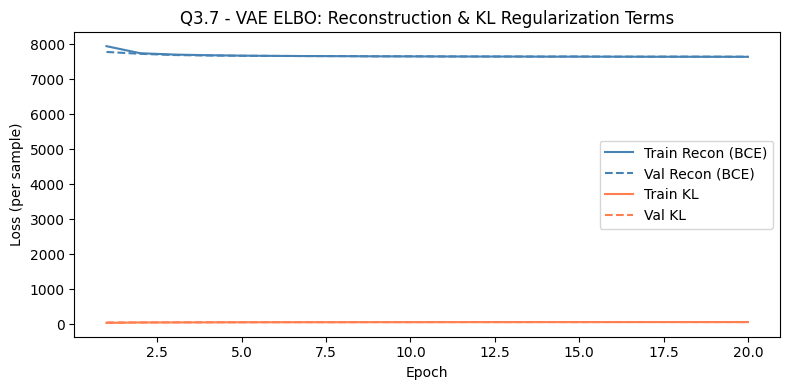

Plot saved as q3_7_elbo_terms.png


In [8]:
# Plot Reconstruction & KL terms over epochs
epochs_range = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, train_recon_hist, label='Train Recon (BCE)', color='steelblue')
ax.plot(epochs_range, val_recon_hist,   label='Val Recon (BCE)',   color='steelblue', linestyle='--')
ax.plot(epochs_range, train_kl_hist,    label='Train KL',          color='coral')
ax.plot(epochs_range, val_kl_hist,      label='Val KL',            color='coral',    linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (per sample)')
ax.set_title('Q3.7 - VAE ELBO: Reconstruction & KL Regularization Terms')
ax.legend()
plt.tight_layout()
plt.savefig('q3_7_elbo_terms.png', dpi=150)
plt.show()
print('Plot saved as q3_7_elbo_terms.png')

---
## Q3.8 - VAE vs. Simple DCGAN

In [9]:
Z_DIM = 100   # GAN noise dimension

class Generator(nn.Module):
    """DCGAN Generator: z (Z_DIM,1,1) -> (3, 64, 64)."""
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            # z -> 4x4
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False), nn.BatchNorm2d(512), nn.ReLU(True),
            # 4 -> 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
            # 8 -> 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            # 16 -> 32
            nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(True),
            # 32 -> 64
            nn.ConvTranspose2d( 64,   3, 4, 2, 1, bias=False), nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """DCGAN Discriminator: (3, 64, 64) -> scalar real/fake logit."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(  3,  64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d( 64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Conv2d(512,   1, 4, 1, 0, bias=False), nn.Flatten(),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

In [10]:
# DCGAN uses Tanh output -> images in [-1, 1]; normalise accordingly
transform_gan = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # [0,1] -> [-1,1]
])

full_dataset.transform = transform_gan
gen_split = torch.Generator().manual_seed(42)
train_gan, _, _ = random_split(full_dataset, [n_train, n_val, n_test], generator=gen_split)
train_loader_gan = DataLoader(train_gan, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [11]:
EPOCHS_GAN = 20
LR_GAN     = 2e-4
BETAS      = (0.5, 0.999)

netG = Generator(Z_DIM).to(device)
netD = Discriminator().to(device)

optG = optim.Adam(netG.parameters(), lr=LR_GAN, betas=BETAS)
optD = optim.Adam(netD.parameters(), lr=LR_GAN, betas=BETAS)
criterion_bce = nn.BCEWithLogitsLoss()

g_losses, d_losses = [], []
fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)  # fixed for visualisation

for epoch in range(1, EPOCHS_GAN + 1):
    g_epoch = d_epoch = 0.0
    for real, _ in train_loader_gan:
        real = real.to(device)
        B = real.size(0)

        # Discriminator step
        noise = torch.randn(B, Z_DIM, 1, 1, device=device)
        fake  = netG(noise).detach()
        d_loss = (criterion_bce(netD(real), torch.ones(B,  device=device)) +
                  criterion_bce(netD(fake), torch.zeros(B, device=device)))
        optD.zero_grad(); d_loss.backward(); optD.step()

        # Generator step
        noise = torch.randn(B, Z_DIM, 1, 1, device=device)
        g_loss = criterion_bce(netD(netG(noise)), torch.ones(B, device=device))
        optG.zero_grad(); g_loss.backward(); optG.step()

        g_epoch += g_loss.item(); d_epoch += d_loss.item()

    g_losses.append(g_epoch / len(train_loader_gan))
    d_losses.append(d_epoch / len(train_loader_gan))

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS_GAN} | G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f}')

torch.save(netG.state_dict(), 'dcgan_G_q3_8.pt')
print('Generator saved as dcgan_G_q3_8.pt')

Epoch   5/20 | G: 3.6129 | D: 0.5228
Epoch  10/20 | G: 4.2917 | D: 0.3373
Epoch  15/20 | G: 4.8372 | D: 0.2173
Epoch  20/20 | G: 4.8982 | D: 0.2047
Generator saved as dcgan_G_q3_8.pt


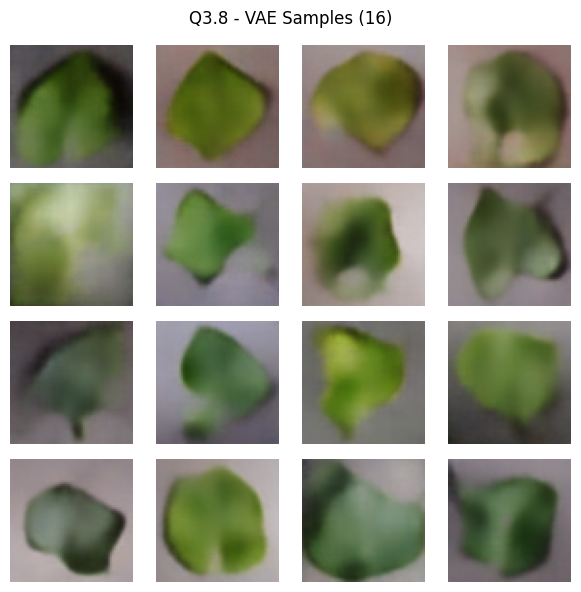

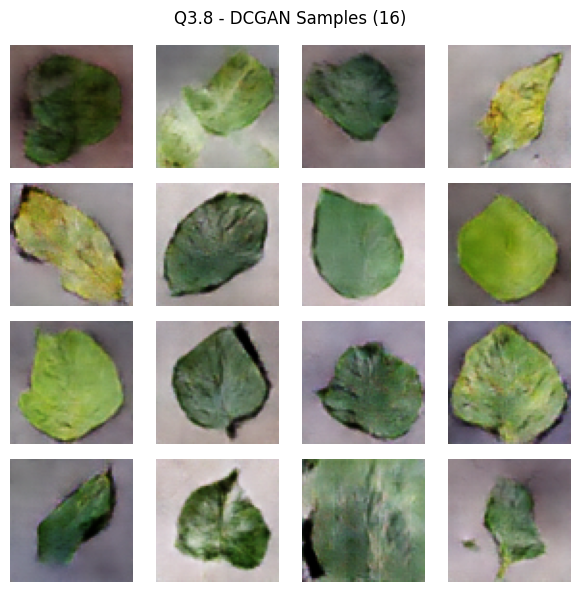

In [12]:
# Restore [0,1] transform for VAE sampling
full_dataset.transform = transform

def show_grid(imgs, title, fname):
    """Display a 4x4 grid of images (tensor B x C x H x W in [0,1])."""
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img in zip(axes.flat, imgs):
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

# 16 samples from VAE
vae.eval()
with torch.no_grad():
    z_vae = torch.randn(16, LATENT_DIM, device=device)
    vae_samples = vae.decode(z_vae).clamp(0, 1)
show_grid(vae_samples, 'Q3.8 - VAE Samples (16)', 'q3_8_vae_samples.png')

# 16 samples from DCGAN
netG.eval()
with torch.no_grad():
    gan_samples = (netG(fixed_noise) + 1) / 2  # Tanh [-1,1] -> [0,1]
show_grid(gan_samples, 'Q3.8 - DCGAN Samples (16)', 'q3_8_dcgan_samples.png')

### Why does the VAE ELBO produce blurrier images than the GAN minimax objective?

**VAE ELBO:**
$$\mathcal{L}_{\text{ELBO}} = \mathbb{E}_{q_{\phi}(z|x)}[\log p_{\theta}(x|z)] - D_{\text{KL}}(q_{\phi}(z|x)\|p(z))$$

The reconstruction term optimises a **pixel-wise BCE/MSE** averaged over the posterior. For any multi-modal data distribution the decoder minimises this by outputting the expected value $\hat{x} = \mathbb{E}[x|z]$ — a weighted average of all plausible pixel values — which is inherently blurry.

**GAN minimax:**
$$\min_G \max_D\; \mathbb{E}_x[\log D(x)] + \mathbb{E}_z[\log(1-D(G(z)))]$$

The generator never computes a per-pixel reconstruction loss. It only needs to produce samples that fool $D$. Since $D$ is trained on sharp real images, any blurry output is immediately identified as fake and penalised. This adversarial pressure forces $G$ to commit to **one sharp mode** rather than averaging across modes.

---
## Q3.9 - Frechet Inception Distance (FID)

In [13]:
import csv
from PIL import Image
from torch.utils.data import Dataset

APTOS_DIR = '../Datasets/aptos2019-blindness-detection'

# Inception v3 requires 299x299 inputs
transform_inception = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# 64x64 for DCGAN training
transform_aptos_gan = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

class APTOSDataset(Dataset):
    """Loads APTOS images; optionally filters to a single diagnosis class."""
    def __init__(self, csv_path, img_dir, transform, diagnosis=None):
        with open(csv_path) as f:
            rows = list(csv.DictReader(f))
        if diagnosis is not None:
            rows = [r for r in rows if int(r['diagnosis']) == diagnosis]
        self.samples = [(os.path.join(img_dir, r['id_code'] + '.png'), int(r['diagnosis']))
                        for r in rows]
        self.transform = transform

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label


CSV_PATH = os.path.join(APTOS_DIR, 'train.csv')
IMG_DIR  = os.path.join(APTOS_DIR, 'train_images')

# Class-4 only subset for GAN training
class4_dataset = APTOSDataset(CSV_PATH, IMG_DIR, transform_aptos_gan, diagnosis=4)
class4_loader  = DataLoader(class4_dataset, batch_size=32, shuffle=True, num_workers=0)

# Full APTOS for real FID features
full_aptos_dataset = APTOSDataset(CSV_PATH, IMG_DIR, transform_inception)

print(f'Class-4 images: {len(class4_dataset)} | Full APTOS: {len(full_aptos_dataset)}')

Class-4 images: 295 | Full APTOS: 3662


In [14]:
# Train a fresh DCGAN on Class-4 APTOS images
netG_aptos = Generator(Z_DIM).to(device)
netD_aptos = Discriminator().to(device)

optG_a = optim.Adam(netG_aptos.parameters(), lr=LR_GAN, betas=BETAS)
optD_a = optim.Adam(netD_aptos.parameters(), lr=LR_GAN, betas=BETAS)

EPOCHS_APTOS = 50   # more epochs: only 295 images
for epoch in range(1, EPOCHS_APTOS + 1):
    g_ep = d_ep = 0.0
    for real, _ in class4_loader:
        real = real.to(device)
        B = real.size(0)

        noise = torch.randn(B, Z_DIM, 1, 1, device=device)
        fake  = netG_aptos(noise).detach()
        d_loss = (criterion_bce(netD_aptos(real), torch.ones(B,  device=device)) +
                  criterion_bce(netD_aptos(fake), torch.zeros(B, device=device)))
        optD_a.zero_grad(); d_loss.backward(); optD_a.step()

        noise = torch.randn(B, Z_DIM, 1, 1, device=device)
        g_loss = criterion_bce(netD_aptos(netG_aptos(noise)), torch.ones(B, device=device))
        optG_a.zero_grad(); g_loss.backward(); optG_a.step()

        g_ep += g_loss.item(); d_ep += d_loss.item()

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS_APTOS} | G: {g_ep/len(class4_loader):.4f} | D: {d_ep/len(class4_loader):.4f}')

torch.save(netG_aptos.state_dict(), 'dcgan_aptos_G_q3_9.pt')
print('APTOS Generator saved as dcgan_aptos_G_q3_9.pt')

Epoch  10/50 | G: 6.4109 | D: 0.1073
Epoch  20/50 | G: 5.3676 | D: 0.3337
Epoch  30/50 | G: 2.4603 | D: 0.4312
Epoch  40/50 | G: 3.6841 | D: 0.1680
Epoch  50/50 | G: 4.4656 | D: 0.1083
APTOS Generator saved as dcgan_aptos_G_q3_9.pt


In [15]:
import numpy as np

# Frozen Inception v3 with pool3 (2048-d) features
inception = torchvision.models.inception_v3(weights='DEFAULT', aux_logits=True).to(device)
inception.eval()
# Replace fc with Identity to get 2048-d pool features
inception.fc = nn.Identity()

def extract_inception_features(imgs_tensor):
    """Pass a B x 3 x 299 x 299 tensor through frozen Inception v3.
    Returns numpy array of shape (B, 2048).
    """
    with torch.no_grad():
        feats = inception(imgs_tensor.to(device))
    if isinstance(feats, tuple):   # InceptionOutputs namedtuple
        feats = feats[0]
    return feats.cpu().numpy()


N_FID = 500

# ── Real features (500 APTOS images) ────────────────────────────────────────
real_loader_fid = DataLoader(full_aptos_dataset, batch_size=50, shuffle=False, num_workers=0)
real_feats = []
for imgs, _ in real_loader_fid:
    real_feats.append(extract_inception_features(imgs))
    if sum(f.shape[0] for f in real_feats) >= N_FID:
        break
real_feats = np.concatenate(real_feats, axis=0)[:N_FID]  # (500, 2048)

# ── Fake features (500 generated images) ────────────────────────────────────
# Generate 64x64, upsample to 299x299 for Inception
upsample = transforms.Resize((299, 299))
normalize_inc = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

netG_aptos.eval()
fake_feats = []
collected  = 0
while collected < N_FID:
    batch = min(50, N_FID - collected)
    noise = torch.randn(batch, Z_DIM, 1, 1, device=device)
    with torch.no_grad():
        fake_64 = netG_aptos(noise)        # [-1,1], 64x64
        fake_64 = (fake_64 + 1) / 2        # -> [0,1]
        fake_299 = torch.stack([upsample(img) for img in fake_64])   # 299x299
        fake_299 = normalize_inc(fake_299) # normalise for Inception
    fake_feats.append(extract_inception_features(fake_299))
    collected += batch
fake_feats = np.concatenate(fake_feats, axis=0)[:N_FID]  # (500, 2048)

print(f'Real features: {real_feats.shape} | Fake features: {fake_feats.shape}')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/bitupan/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100.0%


Real features: (500, 2048) | Fake features: (500, 2048)


In [16]:
from scipy.linalg import sqrtm

def compute_fid(feat_real, feat_fake):
    """FID = ||mu_r - mu_f||^2 + Tr(C_r + C_f - 2*sqrt(C_r @ C_f))"""
    mu_r, mu_f = feat_real.mean(0), feat_fake.mean(0)
    C_r = np.cov(feat_real, rowvar=False)
    C_f = np.cov(feat_fake, rowvar=False)

    mean_sq_diff = np.sum((mu_r - mu_f) ** 2)
    # Matrix square root via scipy
    sqrt_Cr_Cf = sqrtm(C_r @ C_f)
    if np.iscomplexobj(sqrt_Cr_Cf):    # numerical artefact: discard tiny imaginary part
        sqrt_Cr_Cf = sqrt_Cr_Cf.real
    trace_term = np.trace(C_r + C_f - 2 * sqrt_Cr_Cf)
    return float(mean_sq_diff + trace_term)


fid_score = compute_fid(real_feats, fake_feats)
print(f'Q3.9 FID Score: {fid_score:.2f}')

Q3.9 FID Score: 255.94


---
## Q3.10 - Batch Normalization & Mode Collapse

In [17]:
class GeneratorNoBN(nn.Module):
    """DCGAN Generator WITHOUT BatchNorm: z (Z_DIM,1,1) -> (3, 64, 64)."""
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=True), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=True), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=True), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=True), nn.ReLU(True),
            nn.ConvTranspose2d( 64,   3, 4, 2, 1, bias=True), nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)

In [18]:
# Retrain on APTOS Class-4 WITHOUT BatchNorm in the Generator
netG_nobn = GeneratorNoBN(Z_DIM).to(device)
netD_nobn = Discriminator().to(device)       # Discriminator unchanged

optG_nb = optim.Adam(netG_nobn.parameters(), lr=LR_GAN, betas=BETAS)
optD_nb = optim.Adam(netD_nobn.parameters(), lr=LR_GAN, betas=BETAS)

fixed_noise_nobn = torch.randn(16, Z_DIM, 1, 1, device=device)

for epoch in range(1, EPOCHS_APTOS + 1):
    g_ep = d_ep = 0.0
    for real, _ in class4_loader:
        real = real.to(device)
        B = real.size(0)

        noise = torch.randn(B, Z_DIM, 1, 1, device=device)
        fake  = netG_nobn(noise).detach()
        d_loss = (criterion_bce(netD_nobn(real), torch.ones(B,  device=device)) +
                  criterion_bce(netD_nobn(fake), torch.zeros(B, device=device)))
        optD_nb.zero_grad(); d_loss.backward(); optD_nb.step()

        noise = torch.randn(B, Z_DIM, 1, 1, device=device)
        g_loss = criterion_bce(netD_nobn(netG_nobn(noise)), torch.ones(B, device=device))
        optG_nb.zero_grad(); g_loss.backward(); optG_nb.step()

        g_ep += g_loss.item(); d_ep += d_loss.item()

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS_APTOS} | G: {g_ep/len(class4_loader):.4f} | D: {d_ep/len(class4_loader):.4f}')

print('Training complete (no BatchNorm generator)')

Epoch  10/50 | G: 10.1986 | D: 0.0065
Epoch  20/50 | G: 4.7034 | D: 0.5677
Epoch  30/50 | G: 5.1394 | D: 0.3853
Epoch  40/50 | G: 5.0654 | D: 0.1970
Epoch  50/50 | G: 4.6323 | D: 0.2988
Training complete (no BatchNorm generator)


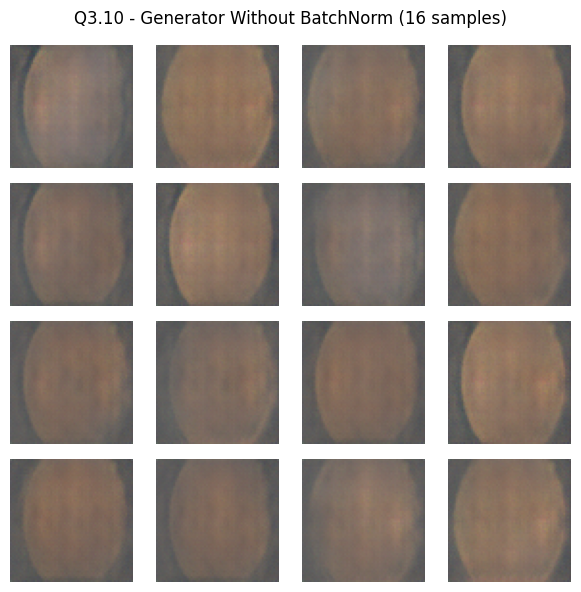

In [19]:
# Generate 4x4 grid from the no-BN generator
netG_nobn.eval()
with torch.no_grad():
    nobn_samples = (netG_nobn(fixed_noise_nobn) + 1) / 2  # -> [0,1]
show_grid(nobn_samples, 'Q3.10 - Generator Without BatchNorm (16 samples)', 'q3_10_nobn_samples.png')

### How does removing BatchNorm exacerbate mode collapse?

**BatchNorm** normalises each feature map across the batch to zero mean and unit variance before passing it to the next layer:
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \cdot \gamma + \beta$$

This has two critical effects on a GAN generator:

1. **Prevents internal covariate shift.** Without BN the distribution of each layer's activations drifts as weights update. Early layers in a deep convnet can saturate or collapse to a single value, forcing all noise vectors $z$ through the same path and collapsing the output distribution to a single mode.

2. **Enforces diversity within a batch.** BN normalises *across the batch dimension*, so if all $B$ samples in a batch are nearly identical (a sign of mode collapse), the normalised variance $\sigma_B^2 \approx 0$ creates an ill-conditioned division — the gradient signal becomes extremely large and unstable. This restoring force actively prevents homogeneity. Without it, nothing stops all outputs from converging to the same image that best fools the discriminator.

Mathematically, mode collapse corresponds to the generator mapping the entire latent space $p(z)$ to a single (or very few) point(s) in image space:
$$G_{\theta}(z) \approx x^* \quad \forall\, z \sim p(z)$$
Without BatchNorm the gradient of $G$ through layers of unconstrained activations provides no resistance to this collapse, whereas with BN the batch statistics inject a diversity-preserving regulariser at every layer.